In [ ]:
import pandas as pd, numpy as np
import clickhouse_connect as cc

client = cc.get_client(
    host='10.11.1.6',
    port=8123,
    username='clickhouse',
    password='clickhouse',
    database='directory_local'
)

In [ ]:
import numpy as np
import pandas as pd
from filterpy.kalman import KalmanFilter

In [ ]:
toxicity = client.query_df("""
                           WITH sec AS
                               (SELECT toStartOfSecond(date_time)                           AS t,
                                       argMax((best_bid + best_ask) / 2, date_time)         AS mid,
                                       argMax(z9, date_time)                                AS z9,
                                       sum(bookDelta)                                       AS book_delta,
                                       sum(deltaBid) - sum(deltaAsk)                        AS d_flow,
                                       argMax(if(bid_depth > 0 AND ask_depth > 0,
                                                 log(bid_depth / ask_depth), 0), date_time) AS depth_lr
                                FROM directory_local.order_book_imbalance
                               where date_time >= now() - INTERVAL 48 HOUR
                               AND symbol = 'XAUUSDT'
                               AND best_bid
                              > 0
                               AND best_ask
                              > 0
                           GROUP BY t)
                           SELECT toStartOfInterval(t, INTERVAL 1 second) AS time,
       round(avg(
                     greatest(-3.0, least(3.0, z9))
                         + coalesce(greatest(-3.0, least(3.0, (book_delta - c.mu_bd) / nullIf(c.sd_bd, 0))), 0)
                         + coalesce(greatest(-3.0, least(3.0, (d_flow - c.mu_df) / nullIf(c.sd_df, 0))), 0)
                         + coalesce(greatest(-3.0, least(3.0, (depth_lr - c.mu_dl) / nullIf(c.sd_dl, 0))), 0)),
             3)                                AS toxicity_score,
       round(any(c.thr_up), 3)                 AS threshold_up,
       round(any(c.thr_dn), 3)                 AS threshold_dn,
       argMax(mid, t)                          AS mid
                           FROM sec
                               CROSS JOIN (SELECT * FROM mv_toxicity_calib WHERE symbol = 'XAUUSDT' ORDER BY calibrated_at DESC LIMIT 1) AS c
                           GROUP BY time
                           ORDER BY time
                           """
)

pd_toxicity = pd.DataFrame(toxicity)


In [ ]:
pd_toxicity

In [24]:
kf = KalmanFilter(dim_x=1, dim_z=1)

kf.x = np.array([[pd_toxicity['toxicity_score'].iloc[0]]])


In [25]:

kf.F = np.array([[1.]])
kf.H = np.array([[1.]])
kf.P = np.array([[10.]])
kf.R = np.array([[1]])
kf.Q = np.array([[0.0001]])


In [26]:

smoothed = []

for z in pd_toxicity['toxicity_score']:
    kf.predict()
    kf.update(np.array([[z]]))
    smoothed.append(kf.x[0, 0])

pd_toxicity['toxicity_score_filter'] = smoothed

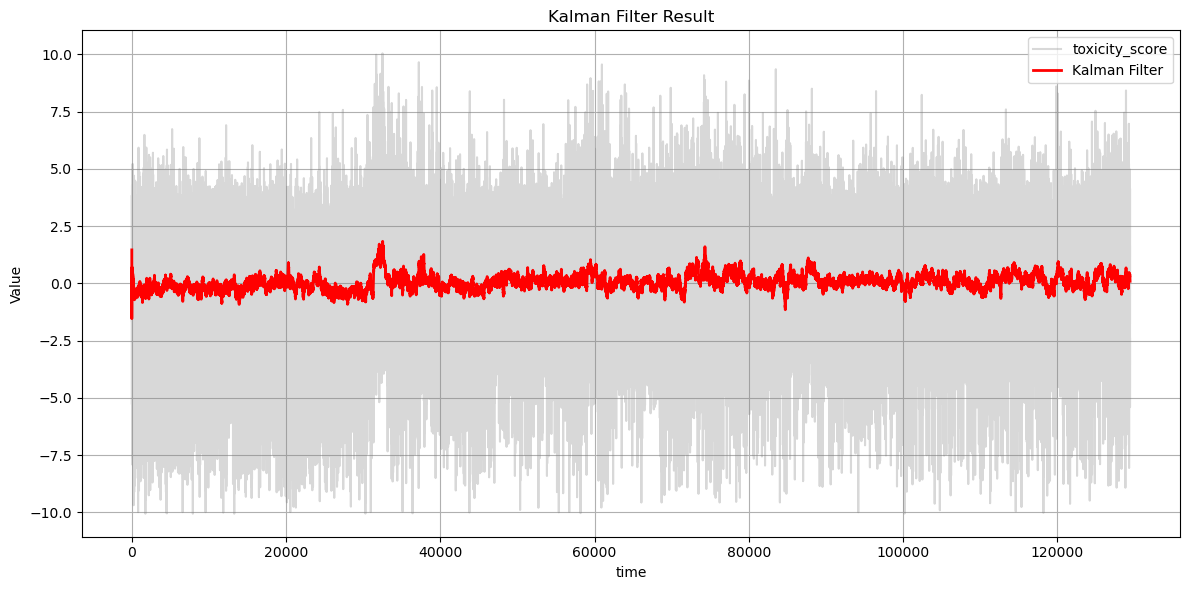

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(pd_toxicity.index, pd_toxicity['toxicity_score'],
         label='toxicity_score',
         color='gray',
         alpha=0.3)

plt.plot(pd_toxicity.index, pd_toxicity['toxicity_score_filter'],
         label='Kalman Filter',
         color='red',
         linewidth=2)

plt.title('Kalman Filter Result')
plt.xlabel('time')
plt.ylabel('Value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()